In [2]:
from __future__ import print_function
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import torchvision
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
import torchvision
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import torchvision.transforms as transforms

from torch.autograd import Variable
import pylab
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# Standard MNIST preprocessing
transform = transforms.Compose([
    transforms.Resize(32), # Resizing to 32x32 often works better with DCGAN layers
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

In [ ]:
num_gpu = 1 if torch.cuda.is_available() else 0
# load the models
from dcgan import Discriminator, Generator

D = Discriminator(ngpu=1).eval()
G = Generator(ngpu=1).eval()

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

# 2. Load the weights using that device
D.load_state_dict(torch.load('weights/netD_epoch_99.pth', map_location=device))
G.load_state_dict(torch.load('weights/netG_epoch_99.pth', map_location=device))

# 3. Move the models to the device
D = D.to(device)
G = G.to(device)

Running on: cpu


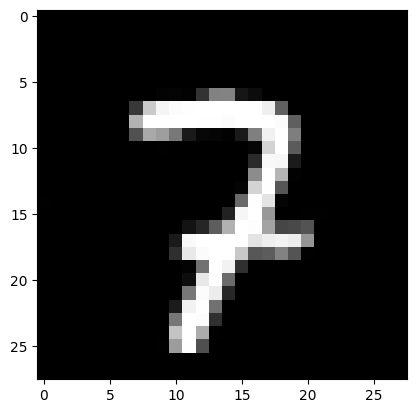

tensor([0.0187], grad_fn=<SqueezeBackward1>)  this shows that the image is mostly generator created (not a real dataset one)


In [5]:
vec = torch.randn(1,100, 1,1).to(device)
image_generated = G(vec)
shit = image_generated.cpu().detach().numpy().reshape(1,28,28)
plt.imshow(shit[0], cmap='gray')
plt.show()
print(D(image_generated), " this shows that the image is mostly generator created (not a real dataset one)")

## training the inverese G+ 

z is the random data created in the latent space, G(z) + noise is the input to G*, whose output is z*, 

z* = G*(G(z) + noise)  

loss = ||z*  - z||^2

In [37]:
# defiing the G* architecture

class InverseGenerator(nn.Module):
    def __init__(self, ngpu, nc=1, nz=100, ndf=64):
        super(InverseGenerator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # Input is (nc) x 28 x 28
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State size: (ndf) x 14 x 14
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State size: (ndf*2) x 7 x 7
            # We use a kernel of 3 here to handle the odd 7x7 dimension transition
            nn.Conv2d(ndf * 2, ndf * 4, 3, 2, 1, bias=False), 
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State size: (ndf*4) x 4 x 4
            nn.Conv2d(ndf * 4, nz, 4, 1, 0, bias=False),
            # Final output is (nz) x 1 x 1
        )

    def forward(self, input):
        if input.is_cuda and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)
        return output

In [38]:
G_inv = InverseGenerator(ngpu=1).to(device)
G_inv.train()
optimizer = optim.Adam(G_inv.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.MSELoss(reduction="none")
epochs = 5000
batch_size = 512
latent_size = 100
noise_factor = 0.05

## training loop (ran on colab)

In [ ]:
# print("Starting Training Loop...")

# for epoch in range(epochs):
#     optimizer.zero_grad()
    
#     # 1. Generate a FRESH batch of random z for this epoch
#     z_true = torch.randn(batch_size, latent_size, 1, 1).to(device)
        
#     # 2. Generate perfect images from z (using no_grad to save memory!)
#     with torch.no_grad():
#         fake_images = G(z_true)
        
#     # 3. Add synthetic corruption (noise)
#     noise = torch.randn_like(fake_images) * noise_factor
#     corrupted_images = fake_images + noise
    
#     # 4. Pass the corrupted images through your Inverse Generator
#     z_recovered = G_inv(corrupted_images)
    
#     # 5. Calculate MSE Loss: |z* - z|^2
#     loss = criterion(z_recovered, z_true)
    
#     # 6. Backpropagation and optimization step
#     loss.backward(gradient=loss)
#     optimizer.step()
    
#     # 7. Print progress every 250 epochs
#     if epoch % 250 == 0 or epoch == epochs - 1:
#         print(f"Epoch [{epoch}/{epochs}] | MSE Loss: {loss.mean().item():.6f}")
        
#     # 8. Manually delete variables to free memory
#     del z_true, fake_images, noise, corrupted_images, z_recovered, loss
#     if torch.cuda.is_available():
#         torch.cuda.empty_cache()

# print("Training Complete!")

Starting Training Loop...
Epoch [0/5000] | MSE Loss: 1.090290
Epoch [250/5000] | MSE Loss: 0.942394
Epoch [500/5000] | MSE Loss: 0.910174
Epoch [750/5000] | MSE Loss: 0.906112
Epoch [1000/5000] | MSE Loss: 0.921706
Epoch [1250/5000] | MSE Loss: 0.917137
Epoch [1500/5000] | MSE Loss: 0.914137
Epoch [1750/5000] | MSE Loss: 0.901592
Epoch [2000/5000] | MSE Loss: 0.894904
Epoch [2250/5000] | MSE Loss: 0.902526
Epoch [2500/5000] | MSE Loss: 0.899770
Epoch [2750/5000] | MSE Loss: 0.894168
Epoch [3000/5000] | MSE Loss: 0.891415
Epoch [3250/5000] | MSE Loss: 0.905780
Epoch [3500/5000] | MSE Loss: 0.879427
Epoch [3750/5000] | MSE Loss: 0.898949
Epoch [4000/5000] | MSE Loss: 0.893620
Epoch [4250/5000] | MSE Loss: 0.896186
Epoch [4500/5000] | MSE Loss: 0.888261
Epoch [4750/5000] | MSE Loss: 0.892298
Epoch [4999/5000] | MSE Loss: 0.901425
Training Complete!


## load the model and run it 

In [ ]:
# torch.save(G_inv.state_dict(), 'weights/netG_inv_epoch_4999.pth')
# torch.save(optimizer.state_dict(), 'weights/optimizer_G_inv_epoch_4999.pth')


In [42]:
G_inv.eval()
G_inv.load_state_dict(torch.load('weights/G_inv_weights.pth', map_location=device))

<All keys matched successfully>

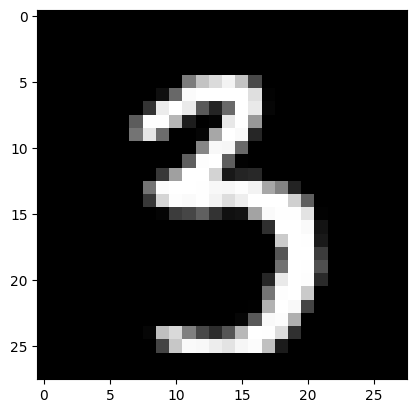

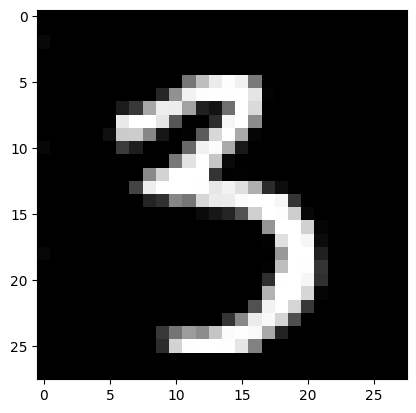

In [43]:
vec = torch.randn(1,100, 1,1).to(device)
image_generated = G(vec)
vec_generated = G_inv(image_generated)
shit = image_generated.cpu().detach().numpy().reshape(1,28,28)
inverse_image_generated = G(vec_generated).cpu().detach().numpy().reshape(28,28)
plt.imshow(shit[0], cmap='gray')
plt.show()
plt.imshow(inverse_image_generated, cmap='gray')
plt.show()

In [46]:
def npgd(A, y, G, G_dagger, T=200, device='cpu', verbose=True):
    G.eval(); G_dagger.eval()
    n = 28 * 28

    # Safe step size: η = 1/β from REC condition
    with torch.no_grad():
        eigvals = torch.linalg.eigvalsh(A.T @ A)
        beta    = eigvals.max().item()
        eta     = 1.0 / beta
        print(f"β = {beta:.4f}  →  η = {eta:.6f}")

    with torch.no_grad():
        x_t = (A.T @ y).to(device)      # x_0 = A^T y

    losses = []
    for t in range(T):
        with torch.no_grad():
            # Gradient step
            w_t   = x_t - eta * (A.T @ (A @ x_t - y))
            w_img = w_t.view(1, 1, 28, 28)   # G expects 28x28

            # Projection: x_{t+1} = G(G†(w_t))
            z_hat   = G_dagger(w_img)
            x_next  = G(z_hat)

            x_t  = x_next.view(n)
            loss = torch.norm(A @ x_t - y).item() ** 2
            losses.append(loss)

        if verbose and (t % 20 == 0 or t == T-1):
            print(f"Iter [{t:>4}/{T}] | ||Ax-y||² = {loss:.6f}")

    return x_next, losses

In [47]:
# ── Run on MNIST test image ───────────────────────────────────
m = 200    # paper uses m=20,50,100,200 for MNIST

with torch.no_grad():
    z_true     = torch.randn(1, 100, 1, 1).to(device)
    x_true_img = G(z_true)                         # (1,1,32,32)
    x_true     = x_true_img.view(28*28).to(device) # flatten 784

# Paper: A_{i,j} ~ N(0, 1/m)
A = torch.randn(m, 28*28).to(device) / (m ** 0.5)

with torch.no_grad():
    y = A @ x_true

x_hat, losses = npgd(A, y, G, G_inv, T=200, device=device)

# ── Metrics ───────────────────────────────────────────────────
with torch.no_grad():
    rel_err = (torch.norm(x_hat.view(784) - x_true) / torch.norm(x_true)).item()
    print(f"Relative error: {rel_err:.4f}")   # target < 0.2 for m=200

β = 8.5657  →  η = 0.116745
Iter [   0/200] | ||Ax-y||² = 404.213921
Iter [  20/200] | ||Ax-y||² = 413.683484
Iter [  40/200] | ||Ax-y||² = 430.370412
Iter [  60/200] | ||Ax-y||² = 412.180422
Iter [  80/200] | ||Ax-y||² = 386.507269
Iter [ 100/200] | ||Ax-y||² = 432.355402
Iter [ 120/200] | ||Ax-y||² = 414.906785
Iter [ 140/200] | ||Ax-y||² = 408.578682
Iter [ 160/200] | ||Ax-y||² = 417.714016
Iter [ 180/200] | ||Ax-y||² = 427.639299
Iter [ 199/200] | ||Ax-y||² = 431.628506
Relative error: 0.7609


In [31]:
def project_onto_range_G(w_img, G, latent_dim=100, device='cpu',
                          lr_adam=0.05, lr_lbfgs=0.1,
                          steps_adam=300, steps_lbfgs=50,
                          restarts=8):
    """
    Two-phase projection:
      Phase 1 — Adam (fast, global exploration across restarts)
      Phase 2 — L-BFGS (precise local convergence from best Adam result)
    """
    G.eval()
    best_loss = float('inf')
    best_z    = None

    # ── Phase 1: Adam with multiple restarts ─────────────────
    for r in range(restarts):
        z = torch.randn(1, latent_dim, 1, 1, device=device, requires_grad=True)
        opt = torch.optim.Adam([z], lr=lr_adam)

        for _ in range(steps_adam):
            opt.zero_grad()
            loss = torch.nn.functional.mse_loss(G(z), w_img)
            loss.backward()
            opt.step()

        with torch.no_grad():
            final_loss = torch.nn.functional.mse_loss(G(z), w_img).item()
        if final_loss < best_loss:
            best_loss = final_loss
            best_z    = z.detach().clone()

    print(f"  Best Adam loss after {restarts} restarts: {best_loss:.6f}")

    # ── Phase 2: L-BFGS refinement from best Adam result ─────
    # L-BFGS uses second-order info → much faster final convergence
    z_refined = best_z.clone().requires_grad_(True)
    opt_lbfgs = torch.optim.LBFGS([z_refined], lr=lr_lbfgs,
                                    max_iter=steps_lbfgs,
                                    line_search_fn='strong_wolfe')

    def closure():
        opt_lbfgs.zero_grad()
        loss = torch.nn.functional.mse_loss(G(z_refined), w_img)
        loss.backward()
        return loss

    opt_lbfgs.step(closure)

    with torch.no_grad():
        final_loss = torch.nn.functional.mse_loss(G(z_refined), w_img).item()
        best_img   = G(z_refined).detach()
    print(f"  L-BFGS refined loss:                  {final_loss:.6f}")

    return best_img, z_refined.detach()

In [32]:
def pgd_on_range_G_v2(A, y, G, eta=0.05, T=30, device='cpu',
                       adam_restarts=8, adam_steps=300,
                       lbfgs_steps=50, verbose=True):
    """
    PGD with two-phase projection. T=30 is enough — each projection
    is now much more accurate so fewer outer steps are needed.
    """
    G.eval()
    n = 28 * 28

    with torch.no_grad():
        x_t = (A.T @ y).to(device)

    loss_history  = []
    proj_loss_history = []

    for t in range(T):
        with torch.no_grad():
            residual = A @ x_t - y
            grad     = A.T @ residual
            w_t      = x_t - eta * grad
            w_img    = w_t.view(1, 1, 28, 28)

        if verbose:
            print(f"\nOuter iter {t+1}/{T}")

        # Two-phase projection
        x_next, z_next = project_onto_range_G(
            w_img, G, device=device,
            lr_adam=0.05,
            steps_adam=adam_steps,
            restarts=adam_restarts,
            steps_lbfgs=lbfgs_steps
        )

        with torch.no_grad():
            x_t      = x_next.view(n)
            meas_loss = torch.norm(A @ x_t - y).item() ** 2
            proj_loss = torch.nn.functional.mse_loss(x_next, w_img).item()
            loss_history.append(meas_loss)
            proj_loss_history.append(proj_loss)

        if verbose:
            print(f"  ||Ax-y||² = {meas_loss:.4f} | proj loss = {proj_loss:.6f}")

    return x_next, loss_history, proj_loss_history

=== Projection Sanity Check ===
  Best Adam loss after 8 restarts: 0.002506
  L-BFGS refined loss:                  0.001529

Projection MSE on G(z): 0.001529
Target: < 0.001  |  FAIL — increase steps/restarts


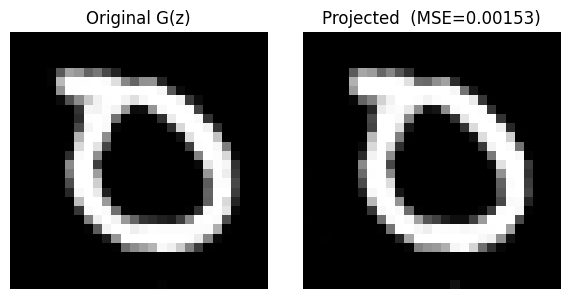

In [33]:
# ── Sanity check projection quality BEFORE running PGD ───────
# If this fails, PGD has no chance. Target proj_loss < 0.001
print("=== Projection Sanity Check ===")
with torch.no_grad():
    z_test    = torch.randn(1, 100, 1, 1).to(device)
    img_test  = G(z_test)

proj_img, z_proj = project_onto_range_G(
    img_test, G, device=device,
    lr_adam=0.05, steps_adam=300, restarts=8, steps_lbfgs=50
)

with torch.no_grad():
    proj_err = torch.nn.functional.mse_loss(proj_img, img_test).item()
    print(f"\nProjection MSE on G(z): {proj_err:.6f}")
    print(f"Target: < 0.001  |  {'PASS ✓' if proj_err < 0.001 else 'FAIL — increase steps/restarts'}")

plt.figure(figsize=(6, 3))
plt.subplot(1,2,1); plt.imshow(img_test.cpu().numpy().reshape(28,28), cmap='gray')
plt.title('Original G(z)'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(proj_img.cpu().numpy().reshape(28,28), cmap='gray')
plt.title(f'Projected  (MSE={proj_err:.5f})'); plt.axis('off')
plt.tight_layout(); plt.show()

Using η = 0.181590

Outer iter 1/30
  Best Adam loss after 8 restarts: 0.630508
  L-BFGS refined loss:                  0.628353
  ||Ax-y||² = 86.7898 | proj loss = 0.628353

Outer iter 2/30
  Best Adam loss after 8 restarts: 0.010474
  L-BFGS refined loss:                  0.010015
  ||Ax-y||² = 82.2016 | proj loss = 0.010015

Outer iter 3/30
  Best Adam loss after 8 restarts: 0.011545
  L-BFGS refined loss:                  0.009707
  ||Ax-y||² = 80.7942 | proj loss = 0.009707

Outer iter 4/30
  Best Adam loss after 8 restarts: 0.013234
  L-BFGS refined loss:                  0.010558
  ||Ax-y||² = 80.2025 | proj loss = 0.010558

Outer iter 5/30
  Best Adam loss after 8 restarts: 0.010142
  L-BFGS refined loss:                  0.009599
  ||Ax-y||² = 77.8187 | proj loss = 0.009599

Outer iter 6/30
  Best Adam loss after 8 restarts: 0.010509
  L-BFGS refined loss:                  0.009587
  ||Ax-y||² = 76.1887 | proj loss = 0.009587

Outer iter 7/30
  Best Adam loss after 8 restarts:

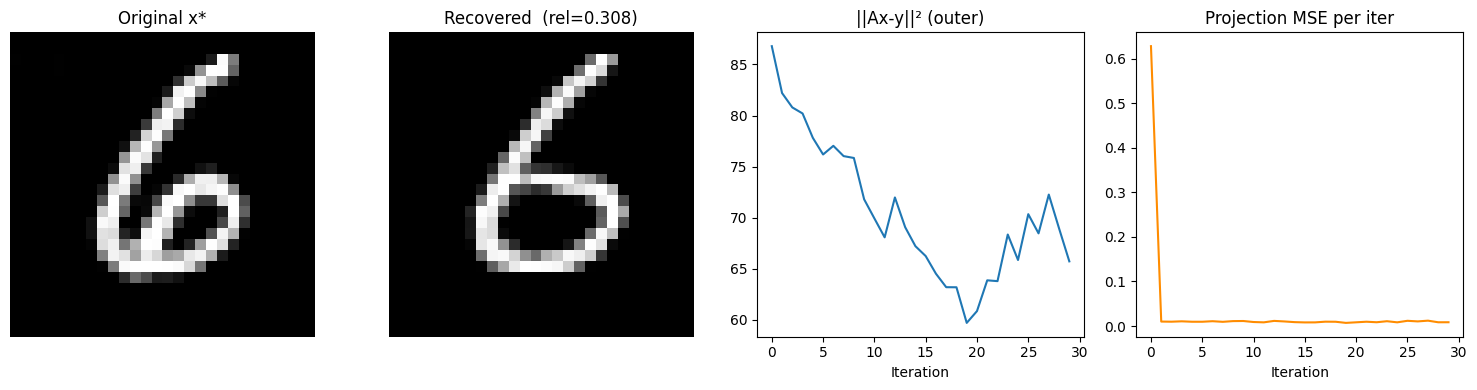

In [34]:
# ── Only run PGD if sanity check passes ──────────────────────
m = 500
n = 28 * 28

with torch.no_grad():
    z_true     = torch.randn(1, 100, 1, 1).to(device)
    x_true_img = G(z_true)
    x_true     = x_true_img.view(n).to(device)

A = (torch.randn(m, n) / (m ** 0.5)).to(device)
with torch.no_grad():
    y        = A @ x_true
    eta_safe = (0.9 / torch.linalg.eigvalsh(A.T @ A).max()).item()
    print(f"Using η = {eta_safe:.6f}")

x_hat, losses, proj_losses = pgd_on_range_G_v2(
    A, y, G, eta=eta_safe, T=30,
    adam_restarts=8, adam_steps=300,
    lbfgs_steps=50, device=device
)

# ── Results ───────────────────────────────────────────────────
with torch.no_grad():
    abs_err = torch.norm(x_hat.view(n) - x_true).item()
    rel_err = abs_err / torch.norm(x_true).item()
    print(f"\nAbsolute error : {abs_err:.4f}")
    print(f"Relative error : {rel_err:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(x_true_img.cpu().numpy().reshape(28,28), cmap='gray')
axes[0].set_title('Original x*'); axes[0].axis('off')
axes[1].imshow(x_hat.cpu().numpy().reshape(28,28), cmap='gray')
axes[1].set_title(f'Recovered  (rel={rel_err:.3f})'); axes[1].axis('off')
axes[2].plot(losses); axes[2].set_title('||Ax-y||² (outer)')
axes[2].set_xlabel('Iteration')
axes[3].plot(proj_losses, color='darkorange')
axes[3].set_title('Projection MSE per iter')
axes[3].set_xlabel('Iteration')
plt.tight_layout(); plt.show()

In [36]:
# G_inv sanity check: G(G_inv(G(z))) should ≈ G(z)
G.eval(); G_inv.eval()
errors = []
with torch.no_grad():
    for _ in range(200):
        z   = torch.randn(1, 100, 1, 1).to(device)
        img = G(z)                        # original generated image
        z_r = G_inv(img)                  # invert it
        img_r = G(z_r)                    # re-generate from recovered z
        err = torch.norm(img_r - img).item()
        errors.append(err)

print(f"G(G_inv(G(z))) mean pixel error: {np.mean(errors):.4f} ± {np.std(errors):.4f}")
# Target: < 0.05. If > 0.2, G_inv is the bottleneck — retrain it.

G(G_inv(G(z))) mean pixel error: 8.3181 ± 2.6163
